In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from gammapy.modeling.models import (
    Models,
    PointSpatialModel,
    PowerLawNormSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpatialModel,
    create_fermi_isotropic_diffuse_model,
)
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL
from astropy.coordinates import SkyCoord
import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [ ]:
catalog_4fgl[]

In [3]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/fermi_config_rcw86_celestial.yaml', logging={'verbosity': 3})

2025-05-13 10:35:20 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [4]:
gta.config

{'logging': {'prefix': '', 'chatter': 3, 'verbosity': 3},
 'fileio': {'outdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial',
  'scratchdir': '/scratch',
  'workdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial',
  'logfile': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/fermipy.log',
  'savefits': True,
  'workdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$'],
  'outdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$|\\.png$|\\.pdf$|\\.yaml$'],
  'usescratch': False},
 'optimizer': {'optimizer': 'MINUIT',
  'tol': 0.001,
  'max_iter': 100,
  'init_lambda': 0.0001,
  'retries': 3,
  'min_fit_quality': 2,
  'verbosity': 0},
 'binning': {'projtype': 'WCS',
  'proj': 'AIT',
  'coordsys': 'CEL',
  'npix': None,
  'roiwidth': 4.0,
  'binsz': 0.02,
  'binsperdec': 8.0,
  'enumbins': None,
  'hpx_ordering_scheme': 'RING',
  'hpx_order': 10,
  'hpx_ebin': True},


In [4]:
gta.setup()

2025-05-08 10:06:18 INFO    GTAnalysis.setup(): Running setup.
2025-05-08 10:06:18 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-05-08 10:06:18 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-05-08 10:06:18 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-05-08 10:06:18 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 54683.000000 from DATE-OBS.
Set MJD-END to 60706.999988 from DATE-END'. [astropy.wcs.wcs]
2025-05-08 10:06:18 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-05-08 10:06:18 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-05-08 10:06:18 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2025-05-08 10:06:21 INFO    GTAnalysis.setup(): Initializing source properties
2025-05-08 10:06:23 INFO    GTAnalysis.setup(): Finished setup.


In [5]:
#gta.sed("4FGL J1516.1-6429")

2025-05-08 10:06:25 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/initial_00.xml...
2025-05-08 10:06:25 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/initial.fits...
2025-05-08 10:06:27 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-05-08 10:06:28 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/initial.npy...


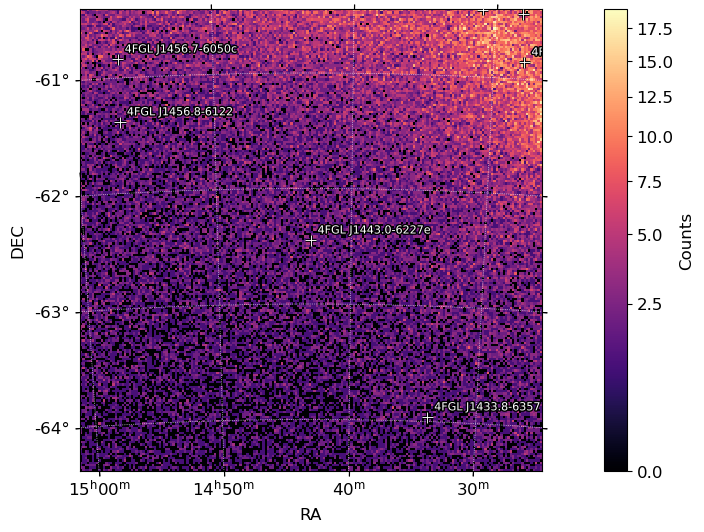

In [5]:
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

In [6]:
gta.print_model()

2025-05-08 10:06:30 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.000   1.695  1.33e-05   1.47       nan       338.5     
4FGL J1433.8-6357      1.834   1.790  1.06e-06   2.70       nan       265.4     
4FGL J1456.8-6122      1.942   1.083  9.92e-07   2.26       nan        87.5     
4FGL J1456.7-6050c     2.290   1.338  2.39e-06   1.42       nan        28.4     
4FGL J1427.8-6051      2.409   2.795   8.5e-06   2.62       nan      1628.3     
4FGL J1430.9-6024c     2.493   1.309  1.85e-06   2.82       nan       103.7     
4FGL J1428.0-6026c     2.689   0.633   3.4e-06   3.38       nan       247.9     
isodiff                  ---   1.000    0.0313   2.12       nan      1497.7     
galdiff                  ---   1.000     0.132   0.00       nan     90210.5     



In [16]:
gta.free_sources()

In [18]:
from gammapy.catalog import SourceCatalog4FGL

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [26]:
source_rcw86 = catalog_4fgl["4FGL J1443.0-6227e"]

In [29]:
source_rcw86.data

{'Source_Name': '4FGL J1443.0-6227e',
 'DataRelease': 1,
 'RAJ2000': <Quantity 220.76 deg>,
 'DEJ2000': <Quantity -62.45 deg>,
 'GLON': <Quantity 315.4419 deg>,
 'GLAT': <Quantity -2.3204007 deg>,
 'Conf_68_SemiMajor': <Quantity 0. deg>,
 'Conf_68_SemiMinor': <Quantity 0. deg>,
 'Conf_68_PosAng': <Quantity 0. deg>,
 'Conf_95_SemiMajor': <Quantity 0. deg>,
 'Conf_95_SemiMinor': <Quantity 0. deg>,
 'Conf_95_PosAng': <Quantity 0. deg>,
 'ROI_num': 761,
 'Extended_Source_Name': 'RCW 86            ',
 'Signif_Avg': 15.167515,
 'Pivot_Energy': <Quantity 31680.906 MeV>,
 'Flux1000': <Quantity 5.1422167e-10 1 / (s cm2)>,
 'Unc_Flux1000': <Quantity 7.6599706e-11 1 / (s cm2)>,
 'Energy_Flux100': <Quantity 9.22062e-12 erg / (s cm2)>,
 'Unc_Energy_Flux100': <Quantity 9.564077e-13 erg / (s cm2)>,
 'SpectrumType': 'PowerLaw         ',
 'PL_Flux_Density': <Quantity 1.6952421e-15 1 / (MeV s cm2)>,
 'Unc_PL_Flux_Density': <Quantity 1.671159e-16 1 / (MeV s cm2)>,
 'PL_Index': 1.4709476,
 'Unc_PL_Index':

### Free parameters around roi center with distance 3 deg.

In [7]:
gta.free_sources(free=False)
# Around particular source 
#gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)
gta.free_sources(distance=[3.0],free=True)
gta.print_model()

2025-05-08 10:06:45 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1443.0-6227e    : ['Prefactor', 'Index']
2025-05-08 10:06:45 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1433.8-6357     : ['norm', 'alpha', 'beta']
2025-05-08 10:06:45 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.8-6122     : ['Prefactor', 'Index']
2025-05-08 10:06:45 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.7-6050c    : ['Prefactor', 'Index']
2025-05-08 10:06:45 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1427.8-6051     : ['norm', 'alpha', 'beta']
2025-05-08 10:06:45 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1430.9-6024c    : ['norm', 'alpha', 'beta']
2025-05-08 10:06:45 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1428.0-6026c    : ['norm', 'alpha', 'beta']
2025-05-08 10:06:45 INFO    GTAnalysis.free_source(): Freeing parameters for isodiff               : ['Normalization']
2

In [8]:
gta.fit()

2025-05-08 10:06:47 INFO    GTAnalysis.fit(): Starting fit.


Drm_Cache::update Measured counts < 0 4FGL J1430.9-6024c 21 -1.10183e-11 2.74074e-11
5.32657 5.04701 4.03983 2.78554 1.65614 0.860711 0.406036 0.17193 0.0671873 0.0235985 0.00777754 0.00232812 0.000639082 0.000156856 3.4112e-05 6.58394e-06 1.13533e-06 1.74317e-07 2.36091e-08 2.83286e-09 2.97749e-10 2.74074e-11 


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)
2025-05-08 10:06:49 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-05-08 10:06:49 INFO    GTAnalysis.fit(): LogLike:  -168271.622 DeltaLogLike:      234.519 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 234.51865026541054,
 'edm': 0.00012393242419957373,
 'loglike': -168271.62208824587,
 'covariance': array([[ 1.03687297e-05, -4.15503540e-09,  7.01168991e-10,
         -8.66922763e-09, -5.87662242e-11,  5.48449347e-10,
         -8.72980565e-08,  2.94546442e-03, -1.21289911e-09,
         -2.53335073e-11, -5.06108223e-12,  1.04842450e-12,
         -1.72644609e-11, -1.87376271e-11, -2.62647401e-13,
         -2.56554607e-12, -2.08735998e-11, -1.41726879e-11,
         -5.74798562e-11,  3.49594717e-11, -8.95614062e-10],
        [-4.15503540e-09,  1.61028543e-06,  2.73383388e-10,
         -1.95542313e-09, -4.85067537e-10, -1.08648771e-10,
         -3.00646178e-08,  1.01438394e-03, -4.17708506e-10,
         -1.09845182e-11, -2.78200705e-12,  4.90370466e-13,
         -6.86357384e-12, -8.34877538e-12, -1.40248288e-13,
         -1.38278337e-12, -1.08528324e-11, -7.71151714e-12,
         -1.82349470e-11,  1.95643024e-12, -2.

In [9]:
gta.print_model()

2025-05-08 10:06:49 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.000   1.639  1.21e-05   1.53    188.15       359.8    *
4FGL J1433.8-6357      1.834   1.712  9.35e-07   2.73     40.10       232.1    *
4FGL J1456.8-6122      1.942   1.899   1.6e-06   2.86     37.81       243.7    *
4FGL J1456.7-6050c     2.290   0.032  3.59e-06   3.61    136.66       555.6    *
4FGL J1427.8-6051      2.409   2.719  1.23e-05   3.11    631.01      2547.4    *
4FGL J1430.9-6024c     2.493   0.000  9.94e-11   2.47     -0.00         0.0    *
4FGL J1428.0-6026c     2.689   1.136  2.28e-05   1.55     23.84       432.0    *
isodiff                  ---   0.637      0.02   2.12      8.56       953.8    *
galdiff                  ---   0.947     0.123   0.01 111087.77     84935.2    *



In [10]:
plt.clf()
tsmap_excluded = gta.tsmap(prefix='TSmap_ecluded',make_plots=True, exclude = gta.roi.sources[0].name)

2025-05-08 10:07:03 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-08 10:07:03 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-08 10:08:09 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-08 10:08:11 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/TSmap_ecluded_pointsource_powerlaw_2.00_tsmap.npy
2025-05-08 10:08:11 INFO    GTAnalysis.tsmap(): Execution time: 68.45 s


<Figure size 640x480 with 0 Axes>

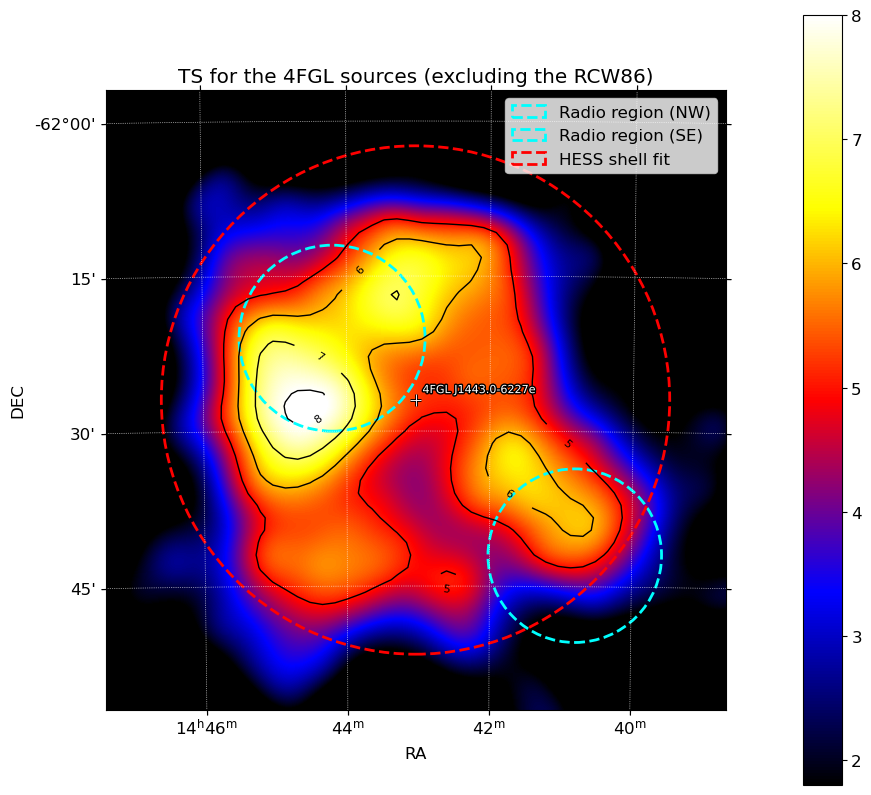

In [24]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi,
               cmap='ds9_b',
               label_ts_threshold=10.0)

plt.figure(figsize=(10, 10))

p.plot(interpolation='bicubic',
       zoom=4,
       vmin=1.8,
       vmax=8,
       levels=[5, 6, 7, 8 ])

NE_region = SkyCoord(221.05, -62.35, unit='deg', frame='icrs')
SW_region = SkyCoord(220.20, -62.70, unit='deg', frame='icrs')
shell_pos = SkyCoord(gta.roi.sources[0]['ra'],
                     gta.roi.sources[0]['dec'],
                     unit='deg', frame='icrs')

c1 = p.draw_circle(0.15, skydir=NE_region,
                   edgecolor='cyan',
                   linewidth=2.0,
                   linestyle='--',
                   label='Radio region (NW)')

c2 = p.draw_circle(0.14, skydir=SW_region,
                   edgecolor='cyan',
                   linewidth=2.0,
                   linestyle='--',
                   label='Radio region (SE)')

c3 = p.draw_circle(0.41, skydir=shell_pos,
                   edgecolor='red',
                   linewidth=2.0,
                   linestyle='--',
                   label='HESS shell fit')

plt.legend(loc='upper right')
plt.title("TS for the 4FGL sources (excluding the RCW86)")
plt.show()

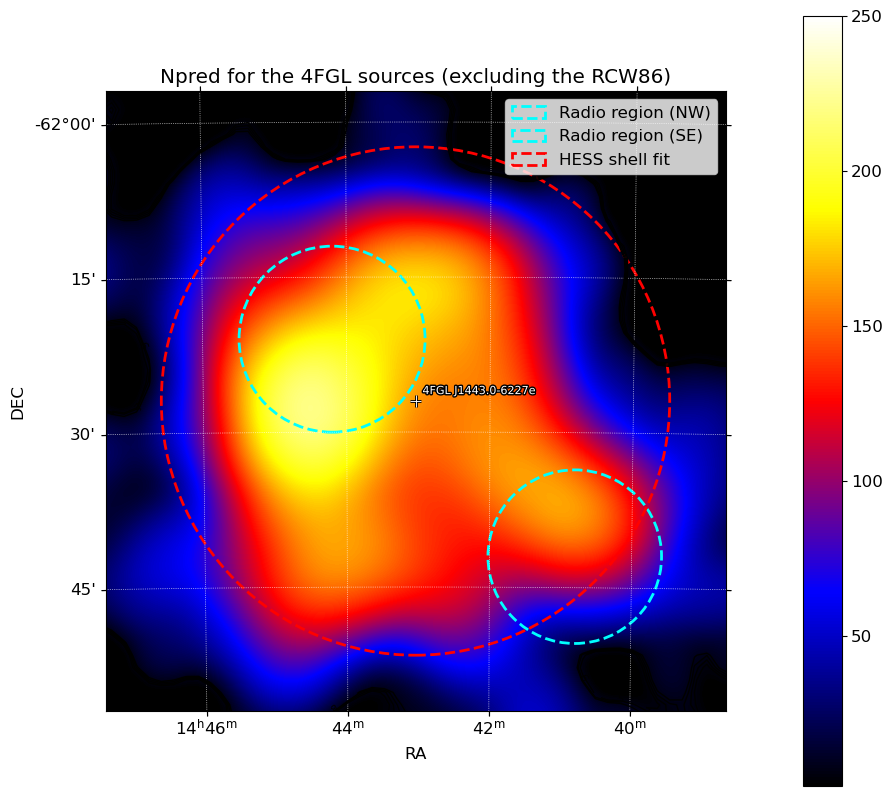

In [31]:
p = ROIPlotter(tsmap_excluded['npred'], roi=gta.roi,
               cmap='ds9_b',
               label_ts_threshold=10.0)

plt.figure(figsize=(10, 10))

p.plot(interpolation='bicubic',
       zoom=4,
       vmin=1.8,
       vmax=250,
       levels=[5, 6, 7, 8 ])

NE_region = SkyCoord(221.05, -62.35, unit='deg', frame='icrs')
SW_region = SkyCoord(220.20, -62.70, unit='deg', frame='icrs')
shell_pos = SkyCoord(gta.roi.sources[0]['ra'],
                     gta.roi.sources[0]['dec'],
                     unit='deg', frame='icrs')

c1 = p.draw_circle(0.15, skydir=NE_region,
                   edgecolor='cyan',
                   linewidth=2.0,
                   linestyle='--',
                   label='Radio region (NW)')

c2 = p.draw_circle(0.14, skydir=SW_region,
                   edgecolor='cyan',
                   linewidth=2.0,
                   linestyle='--',
                   label='Radio region (SE)')

c3 = p.draw_circle(0.41, skydir=shell_pos,
                   edgecolor='red',
                   linewidth=2.0,
                   linestyle='--',
                   label='HESS shell fit')

plt.legend(loc='upper right')
plt.title("Npred for the 4FGL sources (excluding the RCW86)")
plt.show()

In [11]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-04-16 16:58:10 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-16 16:58:10 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-16 16:59:29 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-16 16:59:31 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-16 16:59:31 INFO    GTAnalysis.tsmap(): Execution time: 81.55 s


<Figure size 640x480 with 0 Axes>

In [13]:
gta.print_roi()

2025-04-16 16:59:33 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1443.0-6227e  SpatialMap     PowerLaw          0.353    189.72       340.7
4FGL J1433.8-6357   PointSource    LogParabola       1.515     35.31       203.8
4FGL J1456.8-6122   PointSource    PowerLaw          2.296       nan        87.5
4FGL J1427.8-6051   PointSource    LogParabola       2.334       nan      1628.3
4FGL J1424.2-6111c  PointSource    LogParabola       2.395       nan       505.0
4FGL J1456.7-6050c  PointSource    PowerLaw          2.639       nan        28.4
isodiff             ConstantValue  FileFunction      -----      4.22       647.6
galdiff             MapCubeFunctio PowerLaw          ----- 104883.66     86622.7



<Figure size 640x480 with 0 Axes>

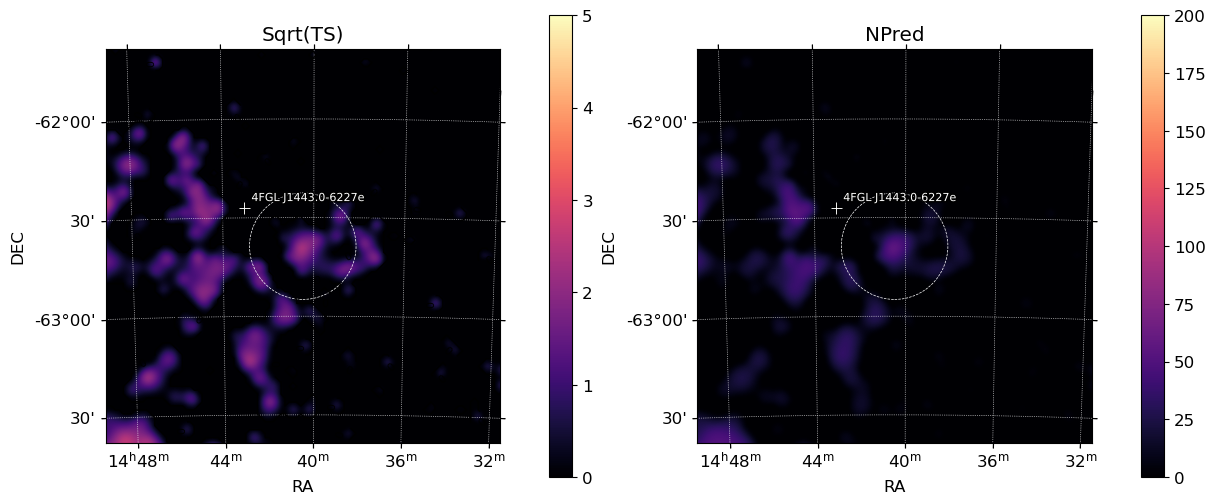

In [35]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

In [170]:
plt.clf()
tsmap_excluded = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True, exclude = gta.roi.sources[0].name)

2025-04-17 11:06:12 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-17 11:06:12 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-17 11:07:16 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-17 11:07:19 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-17 11:07:19 INFO    GTAnalysis.tsmap(): Execution time: 67.78 s


<Figure size 640x480 with 0 Axes>

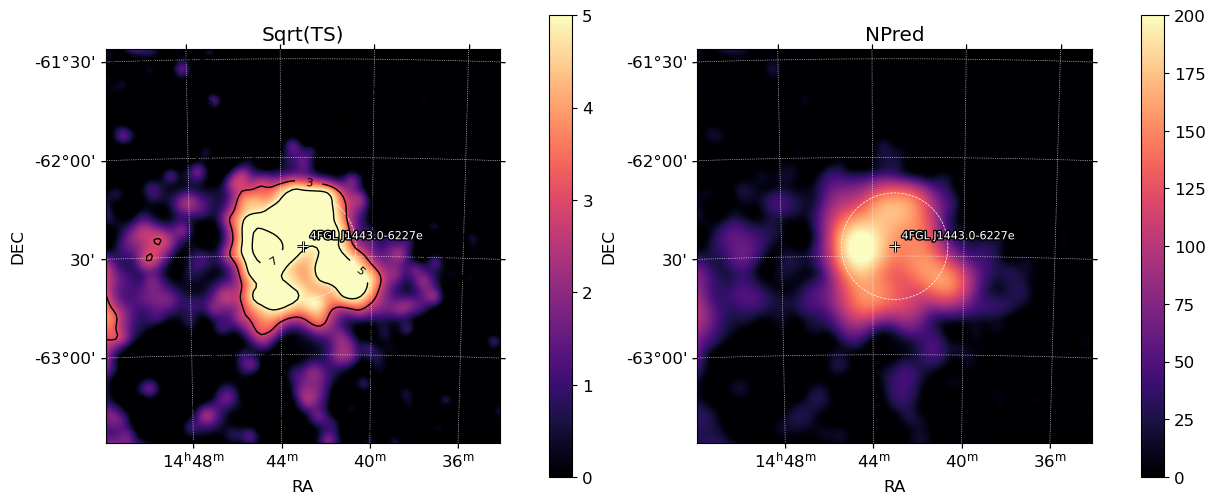

In [62]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_excluded['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_excluded['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

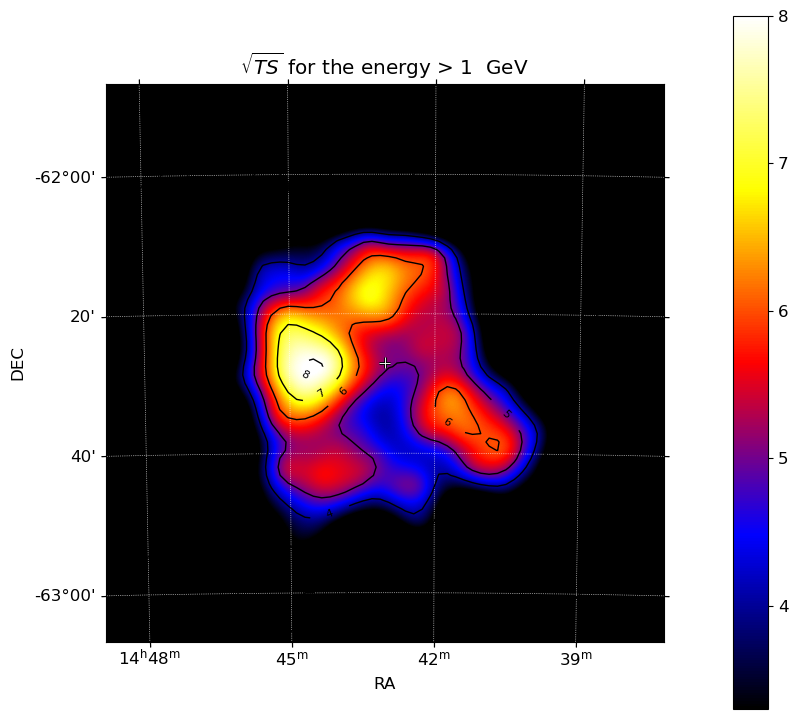

In [203]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               #graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=1000.0)  # optional threshold for labeling
plt.figure(figsize=(9, 9))
#p.plot(interpolation='bicubic', zoom=3,vmin=3.3,vmax=7.5, levels=[0,3,4,5,6,7,8])
p.plot(interpolation='bicubic', zoom=3,vmin=3.3,vmax=8, levels=[0,3,4,5,6,7,8], )
#p.plot(interpolation='bicubic', zoom=3,vmin=3.3,vmax=7)


snr_rcw_86 = SkyCoord(gta.roi.sources[0].radec[0],gta.roi.sources[0].radec[1], unit="deg", frame="icrs")


# p.draw_circle(0.37,  # radius in degrees
#               skydir=snr_rcw_86,
#               edgecolor='cyan',
#               linewidth=2.0,
#               linestyle='--')
plt.title("$\sqrt{TS}$ for the energy > 1  GeV")
plt.show()

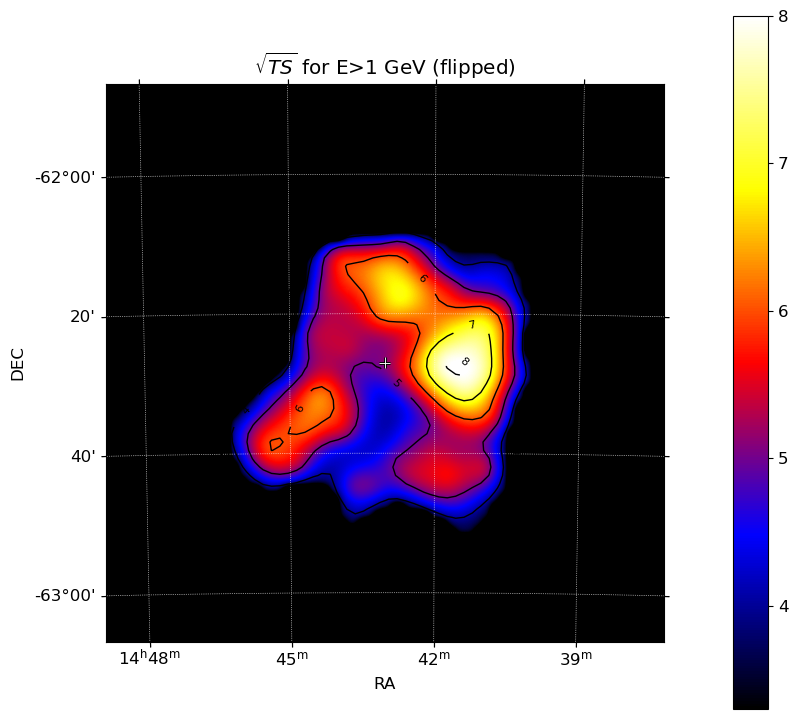

In [183]:
import numpy as np

# 1) make a copy of your map
flipped_map = tsmap.copy()

# 2) reverse it in both axes
#    - [::-1, ::-1] flips bottom↔top and left↔right
flipped_map.data = flipped_map.data[::-1, ::-1]

flipped_map.data = tsmap.data[:, ::-1]
#flipped_map.data = tsmap.data[::-1, :]

# flipped_map.data = tsmap.data[:, ::-1]
# flipped_map.data = flipped_map.data[::-1, :]

p = ROIPlotter(flipped_map, roi=gta.roi, cmap='ds9_b',
               label_ts_threshold=1000.0)

plt.figure(figsize=(9,9))
p.plot(interpolation='bicubic',
       zoom=3,
       vmin=3.3,
       vmax=8,
       levels=[0,3,4,5,6,7,8])
plt.title(r"$\sqrt{TS}$ for E>1 GeV (flipped)")
plt.show()

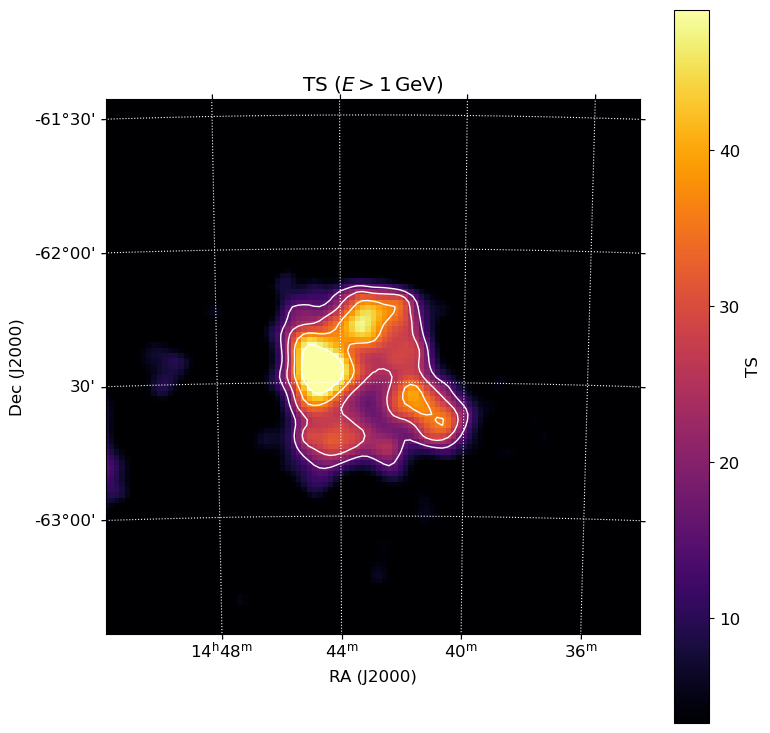

In [175]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt

# 1. Open your TS‑map FITS (make sure it's the file on disk!)
hdu  = fits.open('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/TSmap_start_pointsource_powerlaw_2.00_tsmap.fits')[0]

wcs = WCS(hdu.header)              # header from their FITS file
fig = plt.figure(figsize=(8,8))
ax  = fig.add_subplot(111, projection=wcs)  # TAN by default

im = ax.imshow(hdu.data, origin='lower',
          interpolation='nearest',  # no smoothing
          cmap='inferno', vmin=3.3, vmax=49)
# 4. Overlay your TS contours
levels = [16,25,36, 49]
ax.contour(hdu.data,
           levels=levels,
           transform=ax.get_transform(wcs),
           colors='white',
           linewidths=1)

# 5. Cosmetic labels
ax.set_xlabel('RA (J2000)')
ax.set_ylabel('Dec (J2000)')
ax.coords.grid(True, color='white', ls='dotted')
plt.title(r'TS $(E>1\rm\,GeV)$')
plt.colorbar(im, label=r'TS')
ax.set_xlim(50, 150)
ax.set_ylim(50, 150)
plt.tight_layout()
plt.show()

# Count the counts

In [1]:
from fermipy.gtanalysis import GTAnalysis
from astropy.io import fits

def count_photons_in_region(ra, dec, radius=0.4, emin=1000, emax=600000,
                            tmin=None, tmax=None,
                            evfile='events.fits', scfile='spacecraft.fits'):
    """
    Count photons within a circular region of specified radius around (ra,dec) using Fermipy and the Fermi Science Tools.

    Parameters
    ----------
    ra, dec : float
        Right ascension and declination of the ROI center (in degrees).
    radius : float
        Radius of the circular region (in degrees).
    emin, emax : float
        Minimum and maximum energy (in MeV).
    tmin, tmax : float or None
        Start and stop time (in MET); if None, uses full dataset.
    evfile : str
        Path to the FT1 event file.
    scfile : str
        Path to the spacecraft file (FT2).

    Returns
    -------
    n_photons : int
        Number of photon events in the region.
    """
    config = {
        'data': {'evfile': evfile, 'scfile': scfile},
        'selection': {
            'ra': ra, 'dec': dec, 'rad': radius,
            'emin': emin, 'emax': emax,
            'tmin': tmin, 'tmax': tmax,
            'zmax': 90
        },
        'binning': {
            'roiwidth': radius * 2, 'binsz': radius * 2 / 10
        },
        'irfs': 'P8R3_SOURCE_V2'
    }

    gta = GTAnalysis(config, logging={'verbosity': 2})
    gta.setup()

    # The filtered event file is in gta.files; fallback to the input evfile
    evt_file = gta.files.get('evtfile', evfile)
    with fits.open(evt_file) as hdul:
        n_photons = len(hdul[1].data)
    return n_photons
